# DAS7002 – Big Data Technologies
## PRAC 1 – Data Analysis using Big Data and Distributed Computing Approach

**Student ID:** st20357375

### Objective
This notebook implements a distributed big-data analytics pipeline using
Apache Spark and PySpark for the Chicago Crime dataset. The workflow includes
data engineering, exploratory analysis, spatial-temporal clustering and
distributed predictive modelling.

In [1]:
!pip install -q pyspark

In [2]:
import os
import csv
import pyspark

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

print("PySpark version:", pyspark.__version__)

spark = (
    SparkSession.builder
    .appName("DAS7002_PRAC1_ChicagoCrime")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)

PySpark version: 4.0.4
Spark version: 4.0.4


In [3]:
spark

In [4]:
LOCAL_BASE = "/content/DAS7002_PRAC1"

RAW_PATH = os.path.join(LOCAL_BASE, "raw")
PROCESSED_PATH = os.path.join(LOCAL_BASE, "processed")
OUTPUT_PATH = os.path.join(LOCAL_BASE, "outputs")
FIGURE_PATH = os.path.join(LOCAL_BASE, "figures")

for path in [
    RAW_PATH,
    PROCESSED_PATH,
    OUTPUT_PATH,
    FIGURE_PATH
]:
    os.makedirs(path, exist_ok=True)

print("Project folders created.")
print("Base path:", LOCAL_BASE)

Project folders created.
Base path: /content/DAS7002_PRAC1


In [5]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /


In [6]:
!kaggle datasets download \
-d utkarshx27/crimes-2001-to-present \
-p /content/DAS7002_PRAC1/raw \
--unzip

Dataset URL: https://www.kaggle.com/datasets/utkarshx27/crimes-2001-to-present
License(s): U.S. Government Works
100% 439M/439M [00:05<00:00, 84.8MB/s]



In [7]:
CRIME_PATH = os.path.join(
    RAW_PATH,
    "Crimes_-_2001_to_Present.csv"
)

print("Dataset exists:", os.path.exists(CRIME_PATH))

size_gb = os.path.getsize(CRIME_PATH) / (1024**3)

print(f"Dataset size: {size_gb:.2f} GB")

Dataset exists: True
Dataset size: 1.71 GB


## 1. Data Acquisition and Initial Inspection

The Chicago Crime dataset was obtained from the source specified in the
assessment brief. The raw dataset is processed using Apache Spark rather than
being loaded completely into local memory, supporting scalable distributed
processing.

In [9]:
with open(CRIME_PATH, "r", encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)
    columns = next(reader)
    first_row = next(reader)

print("Number of columns:", len(columns))

for i, col_name in enumerate(columns, start=1):
    print(f"{i:02d}. {col_name}")

Number of columns: 22
01. ID
02. Case Number
03. Date
04. Block
05. IUCR
06. Primary Type
07. Description
08. Location Description
09. Arrest
10. Domestic
11. Beat
12. District
13. Ward
14. Community Area
15. FBI Code
16. X Coordinate
17. Y Coordinate
18. Year
19. Updated On
20. Latitude
21. Longitude
22. Location


# Task 1 – Distributed Data Engineering & Pipeline Construction

## 2. Raw Data Ingestion and Schema Enforcement

The raw crime dataset is initially ingested using an explicit string schema
rather than automatic type inference. Preserving source values in their raw
form allows data quality to be assessed before controlled type conversion is
performed.

In [10]:
from pyspark.sql.types import (
    StructType,
    StructField,
    StringType
)

raw_schema = StructType([
    StructField(
        column,
        StringType(),
        True
    )
    for column in columns
])

crime_raw = (
    spark.read
    .option("header", True)
    .option("mode", "PERMISSIVE")
    .schema(raw_schema)
    .csv(CRIME_PATH)
)

crime_raw.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



In [11]:
crime_raw.select(
    "ID",
    "Date",
    "Primary Type",
    "Arrest",
    "District",
    "Community Area",
    "Year",
    "Latitude",
    "Longitude"
).show(
    10,
    truncate=False
)

+--------+----------------------+------------------+------+--------+--------------+----+------------+-------------+
|ID      |Date                  |Primary Type      |Arrest|District|Community Area|Year|Latitude    |Longitude    |
+--------+----------------------+------------------+------+--------+--------------+----+------------+-------------+
|10224738|09/05/2015 01:30:00 PM|BATTERY           |false |009     |61            |2015|41.815117282|-87.669999562|
|10224739|09/04/2015 11:30:00 AM|THEFT             |false |015     |25            |2015|41.895080471|-87.765400451|
|11646166|09/01/2018 12:01:00 AM|THEFT             |false |006     |44            |2018|NULL        |NULL         |
|10224740|09/05/2015 12:45:00 PM|NARCOTICS         |true  |014     |21            |2015|41.937405765|-87.716649687|
|10224741|09/05/2015 01:00:00 PM|ASSAULT           |false |015     |25            |2015|41.881903443|-87.755121152|
|10224742|09/05/2015 10:55:00 AM|BURGLARY          |false |006     |71  

In [12]:
row_count = crime_raw.count()

print(f"Total rows: {row_count:,}")
print(f"Total columns: {len(crime_raw.columns)}")
print(f"Raw dataset size: {size_gb:.2f} GB")

Total rows: 7,784,664
Total columns: 22
Raw dataset size: 1.71 GB


### Initial Dataset Profile

The raw Chicago Crime dataset contains millions of records across 22
attributes. All fields were initially retained as strings to preserve the
original source values and support explicit validation and type enforcement
before analytical processing.

## 3. Data Quality Assessment

Before type conversion, the raw dataset was assessed for missing values,
malformed timestamps, invalid numeric values, duplicate incident identifiers
and incomplete geographic information. Cleaning decisions were based on the
observed data quality issues rather than indiscriminate row removal.

In [13]:
null_exprs = [
    F.sum(
        F.when(
            F.col(c).isNull() |
            (F.trim(F.col(c)) == ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in crime_raw.columns
]

null_values = crime_raw.agg(*null_exprs).first().asDict()

null_report = [
    (
        column,
        int(null_values[column]),
        round(
            null_values[column] / row_count * 100,
            2
        )
    )
    for column in crime_raw.columns
]

null_df = spark.createDataFrame(
    null_report,
    ["Column", "Missing_Values", "Missing_Pct"]
)

null_df.orderBy(
    F.desc("Missing_Pct")
).show(22, truncate=False)

+--------------------+--------------+-----------+
|Column              |Missing_Values|Missing_Pct|
+--------------------+--------------+-----------+
|Ward                |614848        |7.9        |
|Community Area      |613476        |7.88       |
|X Coordinate        |86848         |1.12       |
|Y Coordinate        |86848         |1.12       |
|Latitude            |86848         |1.12       |
|Longitude           |86848         |1.12       |
|Location            |86848         |1.12       |
|Location Description|10381         |0.13       |
|District            |47            |0.0        |
|ID                  |0             |0.0        |
|FBI Code            |0             |0.0        |
|Case Number         |4             |0.0        |
|Year                |0             |0.0        |
|Date                |0             |0.0        |
|Updated On          |0             |0.0        |
|Block               |0             |0.0        |
|IUCR                |0             |0.0        |


In [14]:
quality_stats = crime_raw.agg(

    F.sum(
        F.when(
            F.col("Date").isNotNull() &
            F.expr(
                "try_to_timestamp(`Date`, 'MM/dd/yyyy hh:mm:ss a')"
            ).isNull(),
            1
        ).otherwise(0)
    ).alias("Invalid_Date"),

    F.sum(
        F.when(
            F.col("Year").isNotNull() &
            F.expr(
                "try_cast(`Year` AS INT)"
            ).isNull(),
            1
        ).otherwise(0)
    ).alias("Invalid_Year"),

    F.sum(
        F.when(
            F.col("Latitude").isNotNull() &
            F.expr(
                "try_cast(`Latitude` AS DOUBLE)"
            ).isNull(),
            1
        ).otherwise(0)
    ).alias("Invalid_Latitude"),

    F.sum(
        F.when(
            F.col("Longitude").isNotNull() &
            F.expr(
                "try_cast(`Longitude` AS DOUBLE)"
            ).isNull(),
            1
        ).otherwise(0)
    ).alias("Invalid_Longitude"),

    F.min(
        F.expr("try_cast(`Year` AS INT)")
    ).alias("Minimum_Year"),

    F.max(
        F.expr("try_cast(`Year` AS INT)")
    ).alias("Maximum_Year")
)

quality_stats.show(truncate=False)

+------------+------------+----------------+-----------------+------------+------------+
|Invalid_Date|Invalid_Year|Invalid_Latitude|Invalid_Longitude|Minimum_Year|Maximum_Year|
+------------+------------+----------------+-----------------+------------+------------+
|0           |0           |0               |0                |2001        |2023        |
+------------+------------+----------------+-----------------+------------+------------+



In [15]:
crime_raw.groupBy("Arrest") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

crime_raw.groupBy("Domestic") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+------+-------+
|Arrest|  count|
+------+-------+
| false|5749900|
|  true|2034764|
+------+-------+

+--------+-------+
|Domestic|  count|
+--------+-------+
|   false|6708370|
|    true|1076294|
+--------+-------+



In [16]:
duplicate_ids = (
    crime_raw
    .groupBy("ID")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_id_count = duplicate_ids.count()

duplicate_record_count = (
    duplicate_ids
    .agg(
        F.sum(
            F.col("count") - 1
        ).alias("Duplicate_Records")
    )
    .first()["Duplicate_Records"]
)

duplicate_record_count = duplicate_record_count or 0

print(
    f"IDs occurring more than once: "
    f"{duplicate_id_count:,}"
)

print(
    f"Additional records associated with duplicate IDs: "
    f"{duplicate_record_count:,}"
)

IDs occurring more than once: 0
Additional records associated with duplicate IDs: 0


### Data Quality Findings

The dataset was generally well structured, with no malformed non-null dates,
years, latitude values or longitude values identified. Missing values were
concentrated in administrative and geographic attributes such as Ward,
Community Area and coordinates.

Rather than removing incomplete records globally, records are retained in the
master dataset and filtered only when a specific analysis requires the missing
attribute. The Arrest variable is also imbalanced and will therefore be
evaluated later using precision, recall, F1-score and ROC rather than accuracy
alone.

The exact duplicate-ID assessment found no repeated incident identifiers;
therefore, no deduplication was required.

## 4. Data Cleaning and Type Enforcement

Following the quality assessment, explicit data types were applied to
analytical attributes. Optional missing geographic and administrative values
were retained to minimise unnecessary information loss.

In [17]:
crime_clean = crime_raw.select(

    F.col("ID")
        .cast("long")
        .alias("ID"),

    F.col("Case Number")
        .alias("Case_Number"),

    F.to_timestamp(
        F.col("Date"),
        "MM/dd/yyyy hh:mm:ss a"
    ).alias("Date"),

    F.col("Block"),

    F.col("IUCR"),

    F.col("Primary Type")
        .alias("Primary_Type"),

    F.col("Description"),

    F.col("Location Description")
        .alias("Location_Description"),

    F.col("Arrest")
        .cast("boolean")
        .alias("Arrest"),

    F.col("Domestic")
        .cast("boolean")
        .alias("Domestic"),

    F.col("Beat")
        .cast("int")
        .alias("Beat"),

    F.col("District")
        .cast("int")
        .alias("District"),

    F.col("Ward")
        .cast("int")
        .alias("Ward"),

    F.col("Community Area")
        .cast("int")
        .alias("Community_Area"),

    F.col("FBI Code")
        .alias("FBI_Code"),

    F.col("X Coordinate")
        .cast("double")
        .alias("X_Coordinate"),

    F.col("Y Coordinate")
        .cast("double")
        .alias("Y_Coordinate"),

    F.col("Year")
        .cast("int")
        .alias("Year"),

    F.to_timestamp(
        F.col("Updated On"),
        "MM/dd/yyyy hh:mm:ss a"
    ).alias("Updated_On"),

    F.col("Latitude")
        .cast("double")
        .alias("Latitude"),

    F.col("Longitude")
        .cast("double")
        .alias("Longitude"),

    F.col("Location")
)

crime_clean.printSchema()

root
 |-- ID: long (nullable = true)
 |-- Case_Number: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary_Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location_Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community_Area: integer (nullable = true)
 |-- FBI_Code: string (nullable = true)
 |-- X_Coordinate: double (nullable = true)
 |-- Y_Coordinate: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated_On: timestamp (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)



In [18]:
clean_count = crime_clean.count()

print(f"Raw records:   {row_count:,}")
print(f"Clean records: {clean_count:,}")
print(
    f"Records lost during type enforcement: "
    f"{row_count - clean_count:,}"
)

Raw records:   7,784,664
Clean records: 7,784,664
Records lost during type enforcement: 0


In [19]:
crime_clean.select(
    "ID",
    "Date",
    "Primary_Type",
    "Arrest",
    "District",
    "Community_Area",
    "Year",
    "Latitude",
    "Longitude"
).show(
    10,
    truncate=False
)

+--------+-------------------+------------------+------+--------+--------------+----+------------+-------------+
|ID      |Date               |Primary_Type      |Arrest|District|Community_Area|Year|Latitude    |Longitude    |
+--------+-------------------+------------------+------+--------+--------------+----+------------+-------------+
|10224738|2015-09-05 13:30:00|BATTERY           |false |9       |61            |2015|41.815117282|-87.669999562|
|10224739|2015-09-04 11:30:00|THEFT             |false |15      |25            |2015|41.895080471|-87.765400451|
|11646166|2018-09-01 00:01:00|THEFT             |false |6       |44            |2018|NULL        |NULL         |
|10224740|2015-09-05 12:45:00|NARCOTICS         |true  |14      |21            |2015|41.937405765|-87.716649687|
|10224741|2015-09-05 13:00:00|ASSAULT           |false |15      |25            |2015|41.881903443|-87.755121152|
|10224742|2015-09-05 10:55:00|BURGLARY          |false |6       |71            |2015|41.74437887

### Analysis-Specific Data Subsets

Missing values were retained in the cleaned master dataset. Spatial analysis
requires valid latitude and longitude values, while community-level analysis
requires a valid Community Area identifier. Separate subsets were therefore
created only where these attributes are necessary.

In [20]:
crime_spatial = crime_clean.filter(
    F.col("Latitude").isNotNull() &
    F.col("Longitude").isNotNull()
)

crime_community = crime_clean.filter(
    F.col("Community_Area").isNotNull()
)

spatial_count = crime_spatial.count()
community_count = crime_community.count()

print(f"Master dataset: {clean_count:,}")

print(
    f"Spatial-analysis records: "
    f"{spatial_count:,} "
    f"({spatial_count / clean_count * 100:.2f}%)"
)

print(
    f"Community-analysis records: "
    f"{community_count:,} "
    f"({community_count / clean_count * 100:.2f}%)"
)

Master dataset: 7,784,664
Spatial-analysis records: 7,697,816 (98.88%)
Community-analysis records: 7,171,188 (92.12%)


## 5. Parquet Storage and Partitioning

The cleaned crime dataset was converted from CSV to Parquet to provide a
columnar storage format suitable for large-scale analytical workloads. The
dataset was partitioned by Year and District so that filtered queries can avoid
scanning irrelevant partitions.

In [22]:
PARQUET_PATH = os.path.join(
    PROCESSED_PATH,
    "crime_parquet"
)

(
    crime_clean
    .write
    .mode("overwrite")
    .partitionBy("Year", "District")
    .parquet(PARQUET_PATH)
)

print("Partitioned crime Parquet created.")

Partitioned crime Parquet created.


In [23]:
!du -sh /content/DAS7002_PRAC1/processed/crime_parquet

473M	/content/DAS7002_PRAC1/processed/crime_parquet


In [24]:
!find /content/DAS7002_PRAC1/processed/crime_parquet \
-maxdepth 2 -type d | head -20

/content/DAS7002_PRAC1/processed/crime_parquet
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=20
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=14
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=17
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=16
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=10
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=4
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=3
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=11
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=1
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=__HIVE_DEFAULT_PARTITION__
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=8
/content/DAS7002_PRAC1/processed/crime_parquet/Year=2006/District=12
/content/DAS7002_PRAC1/processed/crime_parquet/Y

A default Spark/Hive partition is present for the small number of records with
missing District values. These records were intentionally retained in the
master dataset to avoid unnecessary information loss.

In [25]:
crime = spark.read.parquet(PARQUET_PATH)

parquet_count = crime.count()

print(f"Original cleaned records: {clean_count:,}")
print(f"Parquet records:          {parquet_count:,}")
print(
    f"Records lost during Parquet conversion: "
    f"{clean_count - parquet_count:,}"
)

crime.printSchema()

Original cleaned records: 7,784,664
Parquet records:          7,784,664
Records lost during Parquet conversion: 0
root
 |-- ID: long (nullable = true)
 |-- Case_Number: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary_Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location_Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community_Area: integer (nullable = true)
 |-- FBI_Code: string (nullable = true)
 |-- X_Coordinate: double (nullable = true)
 |-- Y_Coordinate: double (nullable = true)
 |-- Updated_On: timestamp (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- District: integer 

In [35]:
partition_test = crime.filter(
    (F.col("Year") == 2023) &
    (F.col("District") == 1)
)

partition_test.explain("formatted")

== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [22]: [ID#625L, Case_Number#626, Date#627, Block#628, IUCR#629, Primary_Type#630, Description#631, Location_Description#632, Arrest#633, Domestic#634, Beat#635, Ward#636, Community_Area#637, FBI_Code#638, X_Coordinate#639, Y_Coordinate#640, Updated_On#641, Latitude#642, Longitude#643, Location#644, Year#645, District#646]
Batched: true
Location: InMemoryFileIndex [file:/content/DAS7002_PRAC1/processed/crime_parquet]
PartitionFilters: [isnotnull(Year#645), isnotnull(District#646), (Year#645 = 2023), (District#646 = 1)]
ReadSchema: struct<ID:bigint,Case_Number:string,Date:timestamp,Block:string,IUCR:string,Primary_Type:string,Description:string,Location_Description:string,Arrest:boolean,Domestic:boolean,Beat:int,Ward:int,Community_Area:int,FBI_Code:string,X_Coordinate:double,Y_Coordinate:double,Updated_On:timestamp,Latitude:double,Longitude:double,Location:string>

(2) ColumnarToRow [codegen id : 1]
I

### Partitioning Validation

The Spark physical execution plan shows partition filters for Year and District.
This confirms that partition pruning can be applied when analytical queries
restrict these attributes, reducing the amount of stored data that must be
scanned.

## 6. Secondary Socio-Economic Data Integration

A secondary Chicago socio-economic dataset was incorporated into the ETL
pipeline to provide community-level contextual information. The dataset
contains indicators including poverty, unemployment, educational attainment,
per-capita income and hardship index.

In [26]:
SOCIO_PATH = os.path.join(
    RAW_PATH,
    "socioeconomic.csv"
)

!wget -q \
"https://data.cityofchicago.org/api/views/kn9c-c2s2/rows.csv?accessType=DOWNLOAD" \
-O "$SOCIO_PATH"

print(
    "Socio-economic file exists:",
    os.path.exists(SOCIO_PATH)
)

print(
    "File size:",
    os.path.getsize(SOCIO_PATH),
    "bytes"
)

Socio-economic file exists: True
File size: 3862 bytes


In [27]:
socio_raw = (
    spark.read
    .option("header", True)
    .option("mode", "PERMISSIVE")
    .csv(SOCIO_PATH)
)

print("Raw socio-economic rows:", socio_raw.count())
print("Raw socio-economic columns:", len(socio_raw.columns))

print(socio_raw.columns)

socio_raw.show(
    10,
    truncate=False
)

Raw socio-economic rows: 78
Raw socio-economic columns: 9
['Community Area Number', 'COMMUNITY AREA NAME', 'PERCENT OF HOUSING CROWDED', 'PERCENT HOUSEHOLDS BELOW POVERTY', 'PERCENT AGED 16+ UNEMPLOYED', 'PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA', 'PERCENT AGED UNDER 18 OR OVER 64', 'PER CAPITA INCOME ', 'HARDSHIP INDEX']
+---------------------+-------------------+--------------------------+--------------------------------+---------------------------+--------------------------------------------+--------------------------------+------------------+--------------+
|Community Area Number|COMMUNITY AREA NAME|PERCENT OF HOUSING CROWDED|PERCENT HOUSEHOLDS BELOW POVERTY|PERCENT AGED 16+ UNEMPLOYED|PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA|PERCENT AGED UNDER 18 OR OVER 64|PER CAPITA INCOME |HARDSHIP INDEX|
+---------------------+-------------------+--------------------------+--------------------------------+---------------------------+--------------------------------------------+--------

In [28]:
socioeconomic = socio_raw.select(

    F.col("Community Area Number")
        .cast("int")
        .alias("Community_Area"),

    F.col("COMMUNITY AREA NAME")
        .alias("Community_Name"),

    F.col("PERCENT OF HOUSING CROWDED")
        .cast("double")
        .alias("Housing_Crowded_Pct"),

    F.col("PERCENT HOUSEHOLDS BELOW POVERTY")
        .cast("double")
        .alias("Poverty_Pct"),

    F.col("PERCENT AGED 16+ UNEMPLOYED")
        .cast("double")
        .alias("Unemployment_Pct"),

    F.col(
        "PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA"
    )
        .cast("double")
        .alias("No_High_School_Diploma_Pct"),

    F.col("PERCENT AGED UNDER 18 OR OVER 64")
        .cast("double")
        .alias("Dependency_Pct"),

    F.col("PER CAPITA INCOME ")
        .cast("double")
        .alias("Per_Capita_Income"),

    F.col("HARDSHIP INDEX")
        .cast("double")
        .alias("Hardship_Index")
)

socioeconomic.printSchema()

root
 |-- Community_Area: integer (nullable = true)
 |-- Community_Name: string (nullable = true)
 |-- Housing_Crowded_Pct: double (nullable = true)
 |-- Poverty_Pct: double (nullable = true)
 |-- Unemployment_Pct: double (nullable = true)
 |-- No_High_School_Diploma_Pct: double (nullable = true)
 |-- Dependency_Pct: double (nullable = true)
 |-- Per_Capita_Income: double (nullable = true)
 |-- Hardship_Index: double (nullable = true)



In [29]:
socioeconomic.filter(
    F.col("Community_Area").isNull() |
    ~F.col("Community_Area").between(1, 77)
).show(
    truncate=False
)

+--------------+--------------+-------------------+-----------+----------------+--------------------------+--------------+-----------------+--------------+
|Community_Area|Community_Name|Housing_Crowded_Pct|Poverty_Pct|Unemployment_Pct|No_High_School_Diploma_Pct|Dependency_Pct|Per_Capita_Income|Hardship_Index|
+--------------+--------------+-------------------+-----------+----------------+--------------------------+--------------+-----------------+--------------+
|NULL          |CHICAGO       |4.7                |19.7       |12.9            |19.5                      |33.5          |28202.0          |NULL          |
+--------------+--------------+-------------------+-----------+----------------+--------------------------+--------------+-----------------+--------------+



In [30]:
socioeconomic = socioeconomic.filter(
    F.col("Community_Area").between(1, 77)
)

print(
    "Valid community-area records:",
    socioeconomic.count()
)

Valid community-area records: 77


In [31]:
socioeconomic.select([
    F.sum(
        F.col(c).isNull().cast("int")
    ).alias(c)
    for c in socioeconomic.columns
]).show(
    truncate=False
)

+--------------+--------------+-------------------+-----------+----------------+--------------------------+--------------+-----------------+--------------+
|Community_Area|Community_Name|Housing_Crowded_Pct|Poverty_Pct|Unemployment_Pct|No_High_School_Diploma_Pct|Dependency_Pct|Per_Capita_Income|Hardship_Index|
+--------------+--------------+-------------------+-----------+----------------+--------------------------+--------------+-----------------+--------------+
|0             |0             |0                  |0          |0               |0                         |0             |0                |0             |
+--------------+--------------+-------------------+-----------+----------------+--------------------------+--------------+-----------------+--------------+



In [32]:
socioeconomic.agg(
    F.count("*").alias("Rows"),
    F.countDistinct(
        "Community_Area"
    ).alias("Distinct_Community_Areas"),
    F.min(
        "Community_Area"
    ).alias("Minimum_Community_Area"),
    F.max(
        "Community_Area"
    ).alias("Maximum_Community_Area")
).show()

+----+------------------------+----------------------+----------------------+
|Rows|Distinct_Community_Areas|Minimum_Community_Area|Maximum_Community_Area|
+----+------------------------+----------------------+----------------------+
|  77|                      77|                     1|                    77|
+----+------------------------+----------------------+----------------------+



In [33]:
community_lookup = (
    socioeconomic
    .select(
        "Community_Area",
        "Community_Name"
    )
    .dropDuplicates()
    .orderBy("Community_Area")
)

community_lookup.show(
    10,
    truncate=False
)

print(
    "Community lookup rows:",
    community_lookup.count()
)

+--------------+---------------+
|Community_Area|Community_Name |
+--------------+---------------+
|1             |Rogers Park    |
|2             |West Ridge     |
|3             |Uptown         |
|4             |Lincoln Square |
|5             |North Center   |
|6             |Lake View      |
|7             |Lincoln Park   |
|8             |Near North Side|
|9             |Edison Park    |
|10            |Norwood Park   |
+--------------+---------------+
only showing top 10 rows
Community lookup rows: 77


### Socio-Economic Data Validation

The source dataset contained a citywide aggregate record in addition to the
numbered Chicago community areas. The aggregate record was excluded because it
does not represent an individual geographic community. The resulting dataset
contains 77 distinct community areas and provides the Community Names lookup
required for later distributed analysis.

The socio-economic indicators represent the 2008–2012 reference period and are
treated as community-level contextual characteristics rather than annual
measurements across the entire crime dataset period.

In [34]:
SOCIO_PARQUET = os.path.join(
    PROCESSED_PATH,
    "socioeconomic_parquet"
)

(
    socioeconomic
    .write
    .mode("overwrite")
    .parquet(SOCIO_PARQUET)
)

print("Socio-economic Parquet created.")

Socio-economic Parquet created.


## 7. Historical Weather Data Integration

Historical daily weather data for Chicago was incorporated to support the
analysis of relationships between weather conditions and crime frequency.

The Open-Meteo Historical Weather API was queried using the ERA5 reanalysis
model for the period 2001–2023, matching the temporal coverage of the crime
dataset. Daily maximum and minimum temperature, precipitation, snowfall and
maximum wind speed were retained for subsequent analysis.

In [39]:
import requests
import pandas as pd

WEATHER_PATH = os.path.join(
    RAW_PATH,
    "chicago_weather.csv"
)

weather_url = (
    "https://archive-api.open-meteo.com/v1/archive"
)

params = {
    "latitude": 41.8781,
    "longitude": -87.6298,
    "start_date": "2001-01-01",
    "end_date": "2023-12-31",
    "daily": ",".join([
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "snowfall_sum",
        "wind_speed_10m_max"
    ]),
    "timezone": "America/Chicago",
    "models": "era5"
}

response = requests.get(
    weather_url,
    params=params,
    timeout=120
)

response.raise_for_status()

weather_json = response.json()

print("Weather API request successful.")
print(
    "Returned timezone:",
    weather_json["timezone"]
)

Weather API request successful.
Returned timezone: America/Chicago


In [40]:
daily = weather_json["daily"]

weather_pd = pd.DataFrame({
    "Weather_Date": daily["time"],
    "TMAX": daily["temperature_2m_max"],
    "TMIN": daily["temperature_2m_min"],
    "PRCP": daily["precipitation_sum"],
    "SNOW": daily["snowfall_sum"],
    "Wind_Speed_Max": daily["wind_speed_10m_max"]
})

weather_pd.to_csv(
    WEATHER_PATH,
    index=False
)

print("Weather CSV created.")
print("Rows:", len(weather_pd))
print("Columns:", len(weather_pd.columns))
print(
    "File exists:",
    os.path.exists(WEATHER_PATH)
)

weather_pd.head()

Weather CSV created.
Rows: 8400
Columns: 6
File exists: True


,Weather_Date,TMAX,TMIN,PRCP,SNOW,Wind_Speed_Max
0,2001-01-01,-4.2,-11.5,0.0,0.00,18.6
1,2001-01-02,-8.5,-14.7,0.0,0.00,23.9
2,2001-01-03,-1.2,-12.9,0.2,0.14,27.3
3,2001-01-04,-0.4,-6.8,0.0,0.00,35.9
4,2001-01-05,2.1,-3.7,0.1,0.00,31.1


### Weather Schema Enforcement

The downloaded weather data was ingested into Spark using an explicit schema.
This prevents analytical fields from depending on automatic type inference and
maintains a consistent schema-enforcement policy across the ETL pipeline.

In [41]:
weather_raw_schema = StructType([
    StructField(
        "Weather_Date",
        StringType(),
        True
    ),
    StructField(
        "TMAX",
        StringType(),
        True
    ),
    StructField(
        "TMIN",
        StringType(),
        True
    ),
    StructField(
        "PRCP",
        StringType(),
        True
    ),
    StructField(
        "SNOW",
        StringType(),
        True
    ),
    StructField(
        "Wind_Speed_Max",
        StringType(),
        True
    )
])

weather_raw = (
    spark.read
    .option("header", True)
    .schema(weather_raw_schema)
    .csv(WEATHER_PATH)
)

print(
    "Raw weather rows:",
    weather_raw.count()
)

weather_raw.printSchema()

Raw weather rows: 8400
root
 |-- Weather_Date: string (nullable = true)
 |-- TMAX: string (nullable = true)
 |-- TMIN: string (nullable = true)
 |-- PRCP: string (nullable = true)
 |-- SNOW: string (nullable = true)
 |-- Wind_Speed_Max: string (nullable = true)



In [42]:
weather = weather_raw.select(

    F.to_date(
        "Weather_Date",
        "yyyy-MM-dd"
    ).alias("Weather_Date"),

    F.col("TMAX")
        .cast("double")
        .alias("TMAX"),

    F.col("TMIN")
        .cast("double")
        .alias("TMIN"),

    F.col("PRCP")
        .cast("double")
        .alias("PRCP"),

    F.col("SNOW")
        .cast("double")
        .alias("SNOW"),

    F.col("Wind_Speed_Max")
        .cast("double")
        .alias("Wind_Speed_Max")
)

weather.printSchema()

weather.show(
    10,
    truncate=False
)

root
 |-- Weather_Date: date (nullable = true)
 |-- TMAX: double (nullable = true)
 |-- TMIN: double (nullable = true)
 |-- PRCP: double (nullable = true)
 |-- SNOW: double (nullable = true)
 |-- Wind_Speed_Max: double (nullable = true)

+------------+----+-----+----+----+--------------+
|Weather_Date|TMAX|TMIN |PRCP|SNOW|Wind_Speed_Max|
+------------+----+-----+----+----+--------------+
|2001-01-01  |-4.2|-11.5|0.0 |0.0 |18.6          |
|2001-01-02  |-8.5|-14.7|0.0 |0.0 |23.9          |
|2001-01-03  |-1.2|-12.9|0.2 |0.14|27.3          |
|2001-01-04  |-0.4|-6.8 |0.0 |0.0 |35.9          |
|2001-01-05  |2.1 |-3.7 |0.1 |0.0 |31.1          |
|2001-01-06  |-0.2|-7.5 |0.0 |0.0 |21.8          |
|2001-01-07  |0.1 |-5.0 |0.0 |0.0 |19.5          |
|2001-01-08  |-5.3|-9.6 |0.0 |0.0 |18.8          |
|2001-01-09  |-4.9|-12.5|0.0 |0.0 |25.3          |
|2001-01-10  |0.4 |-8.4 |0.0 |0.0 |24.9          |
+------------+----+-----+----+----+--------------+
only showing top 10 rows


In [43]:
weather_quality = weather.agg(

    F.count("*")
        .alias("Rows"),

    F.countDistinct(
        "Weather_Date"
    ).alias("Unique_Dates"),

    F.min(
        "Weather_Date"
    ).alias("Start_Date"),

    F.max(
        "Weather_Date"
    ).alias("End_Date"),

    F.sum(
        F.when(
            F.col("TMIN") > F.col("TMAX"),
            1
        ).otherwise(0)
    ).alias("Invalid_Temperature_Range"),

    F.sum(
        F.when(
            F.col("PRCP") < 0,
            1
        ).otherwise(0)
    ).alias("Negative_Precipitation"),

    F.sum(
        F.when(
            F.col("SNOW") < 0,
            1
        ).otherwise(0)
    ).alias("Negative_Snowfall"),

    F.sum(
        F.when(
            F.col("Wind_Speed_Max") < 0,
            1
        ).otherwise(0)
    ).alias("Negative_Wind")
)

weather_quality.show(
    truncate=False
)

+----+------------+----------+----------+-------------------------+----------------------+-----------------+-------------+
|Rows|Unique_Dates|Start_Date|End_Date  |Invalid_Temperature_Range|Negative_Precipitation|Negative_Snowfall|Negative_Wind|
+----+------------+----------+----------+-------------------------+----------------------+-----------------+-------------+
|8400|8400        |2001-01-01|2023-12-31|0                        |0                     |0                |0            |
+----+------------+----------+----------+-------------------------+----------------------+-----------------+-------------+



In [44]:
weather.select([
    F.sum(
        F.col(c).isNull().cast("int")
    ).alias(c)
    for c in weather.columns
]).show(
    truncate=False
)

+------------+----+----+----+----+--------------+
|Weather_Date|TMAX|TMIN|PRCP|SNOW|Wind_Speed_Max|
+------------+----+----+----+----+--------------+
|0           |0   |0   |0   |0   |0             |
+------------+----+----+----+----+--------------+



In [45]:
duplicate_weather_dates = (
    weather
    .groupBy("Weather_Date")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

print(
    "Duplicate weather dates:",
    duplicate_weather_dates
)

Duplicate weather dates: 0


### Weather Quality Findings

The historical weather dataset provides complete daily coverage from
1 January 2001 to 31 December 2023, containing 8,400 unique dates. No missing
values, duplicate dates, invalid temperature ranges or negative precipitation,
snowfall or wind-speed values were identified after schema enforcement.

The resulting weather data therefore provides a complete temporal reference
for later comparison with daily crime frequency. Weather-event indicators are
derived using transparent analytical thresholds to support consistent
exploratory analysis.

### Weather Event Features

Binary weather-event indicators were derived for later comparison with daily
crime frequency. A precipitation event represents measurable precipitation,
heavy precipitation is defined analytically as at least 10 mm per day, a snow
event represents measurable snowfall, a hot day has a maximum temperature of
at least 30°C, and a very cold day has a minimum temperature of -10°C or below.

These thresholds are analytical categories used for comparative exploration
and are not presented as official meteorological warning thresholds.

In [46]:
weather_events = (
    weather

    .withColumn(
        "Precipitation_Event",
        F.when(
            F.col("PRCP") > 0,
            1
        ).otherwise(0)
    )

    .withColumn(
        "Heavy_Precipitation",
        F.when(
            F.col("PRCP") >= 10.0,
            1
        ).otherwise(0)
    )

    .withColumn(
        "Snow_Event",
        F.when(
            F.col("SNOW") > 0,
            1
        ).otherwise(0)
    )

    .withColumn(
        "Hot_Day",
        F.when(
            F.col("TMAX") >= 30.0,
            1
        ).otherwise(0)
    )

    .withColumn(
        "Very_Cold_Day",
        F.when(
            F.col("TMIN") <= -10.0,
            1
        ).otherwise(0)
    )
)

weather_events.select(
    "Weather_Date",
    "TMAX",
    "TMIN",
    "PRCP",
    "SNOW",
    "Precipitation_Event",
    "Heavy_Precipitation",
    "Snow_Event",
    "Hot_Day",
    "Very_Cold_Day"
).show(
    15,
    truncate=False
)

+------------+----+-----+----+----+-------------------+-------------------+----------+-------+-------------+
|Weather_Date|TMAX|TMIN |PRCP|SNOW|Precipitation_Event|Heavy_Precipitation|Snow_Event|Hot_Day|Very_Cold_Day|
+------------+----+-----+----+----+-------------------+-------------------+----------+-------+-------------+
|2001-01-01  |-4.2|-11.5|0.0 |0.0 |0                  |0                  |0         |0      |1            |
|2001-01-02  |-8.5|-14.7|0.0 |0.0 |0                  |0                  |0         |0      |1            |
|2001-01-03  |-1.2|-12.9|0.2 |0.14|1                  |0                  |1         |0      |1            |
|2001-01-04  |-0.4|-6.8 |0.0 |0.0 |0                  |0                  |0         |0      |0            |
|2001-01-05  |2.1 |-3.7 |0.1 |0.0 |1                  |0                  |0         |0      |0            |
|2001-01-06  |-0.2|-7.5 |0.0 |0.0 |0                  |0                  |0         |0      |0            |
|2001-01-07  |0.1 |

In [47]:
weather_events.agg(

    F.sum(
        "Precipitation_Event"
    ).alias("Precipitation_Days"),

    F.sum(
        "Heavy_Precipitation"
    ).alias("Heavy_Precipitation_Days"),

    F.sum(
        "Snow_Event"
    ).alias("Snow_Days"),

    F.sum(
        "Hot_Day"
    ).alias("Hot_Days"),

    F.sum(
        "Very_Cold_Day"
    ).alias("Very_Cold_Days")

).show()

+------------------+------------------------+---------+--------+--------------+
|Precipitation_Days|Heavy_Precipitation_Days|Snow_Days|Hot_Days|Very_Cold_Days|
+------------------+------------------------+---------+--------+--------------+
|              4052|                     715|     1030|     300|           543|
+------------------+------------------------+---------+--------+--------------+



In [48]:
weather_analysis = weather_events.select(
    "Weather_Date",
    "TMAX",
    "TMIN",
    "PRCP",
    "SNOW",
    "Wind_Speed_Max",
    "Precipitation_Event",
    "Heavy_Precipitation",
    "Snow_Event",
    "Hot_Day",
    "Very_Cold_Day"
)

print(
    "Final weather rows:",
    weather_analysis.count()
)

weather_analysis.printSchema()

Final weather rows: 8400
root
 |-- Weather_Date: date (nullable = true)
 |-- TMAX: double (nullable = true)
 |-- TMIN: double (nullable = true)
 |-- PRCP: double (nullable = true)
 |-- SNOW: double (nullable = true)
 |-- Wind_Speed_Max: double (nullable = true)
 |-- Precipitation_Event: integer (nullable = false)
 |-- Heavy_Precipitation: integer (nullable = false)
 |-- Snow_Event: integer (nullable = false)
 |-- Hot_Day: integer (nullable = false)
 |-- Very_Cold_Day: integer (nullable = false)



In [49]:
WEATHER_PARQUET = os.path.join(
    PROCESSED_PATH,
    "weather_parquet"
)

(
    weather_analysis
    .write
    .mode("overwrite")
    .parquet(WEATHER_PARQUET)
)

print("Weather Parquet created.")

Weather Parquet created.


## 8. Data Governance and Ethical Considerations

Although the crime data consists of public administrative records, detailed
geographic information can contribute to neighbourhood stigma or inappropriate
interpretation when analysed without context. Subsequent spatial analysis
therefore focuses on aggregated patterns rather than attempting to profile
individual incidents or residents.

Relationships between crime and socio-economic or weather characteristics are
treated as statistical associations rather than causal explanations. The
socio-economic indicators are also recognised as contextual measures from the
2008–2012 reference period and are not interpreted as annual conditions across
the full 2001–2023 crime dataset.

STOP HERE

## Task 1 Summary

The distributed ETL pipeline processed 7,784,664 Chicago crime records using
Apache Spark and integrated secondary socio-economic and historical weather
datasets. Explicit schema enforcement was applied throughout the pipeline
rather than relying on automatic type inference. Data-quality assessment found
no malformed non-null crime timestamps, years, latitude values or longitude
values, while missing administrative and geographic information was preserved
and handled through analysis-specific subsets.

All 7,784,664 crime records were retained during type conversion. Records with
valid coordinates represented 98.88% of the dataset, while 92.12% contained a
Community Area identifier. An exact duplicate-ID assessment identified no
duplicate crime incidents.

The cleaned crime dataset was converted from the original 1.71 GB CSV into
approximately 473 MB of Parquet data partitioned by Year and District. Spark's
physical execution plan demonstrated partition pruning for queries filtered by
these attributes.

The secondary socio-economic dataset was schema-enforced and restricted to the
77 valid Chicago community areas after identifying and excluding the citywide
aggregate record. A 77-row Community Names lookup was retained for efficient
broadcast joining during subsequent analysis.

Historical ERA5 weather data supplied complete daily coverage from 2001 to
2023, with 8,400 unique dates and no missing observations in the selected
analytical variables. Weather-event indicators were generated and stored in
Parquet format for subsequent crime-weather analysis.

The resulting distributed data pipeline therefore provides clean,
schema-controlled and analysis-ready crime, community, socio-economic and
weather datasets for exploratory analysis, spatial-temporal clustering and
predictive modelling.

# Task 2 – High-Dimensional Exploratory Data Analysis

Task 2 investigates temporal, spatial, socio-economic and weather-related
patterns in Chicago crime using PySpark SQL and distributed Spark operations.

The analysis begins with temporal crime patterns and an efficient broadcast
join between the large crime dataset and the small Community Names lookup.
Subsequent sections calculate rolling community-level crime rates and examine
relationships with socio-economic and weather conditions.

In [66]:
crime.createOrReplaceTempView("crime")
socioeconomic.createOrReplaceTempView("socioeconomic")
weather_analysis.createOrReplaceTempView("weather")
community_lookup.createOrReplaceTempView("community_lookup")

print("Spark SQL views created:")
print("- crime")
print("- socioeconomic")
print("- weather")
print("- community_lookup")

Spark SQL views created:
- crime
- socioeconomic
- weather
- community_lookup


## 9. Temporal Crime Patterns

Temporal patterns were analysed using PySpark SQL. Annual, monthly and
hour-of-day aggregations were performed within Spark so that the complete
crime dataset could be analysed without collecting millions of records into
local memory.

In [67]:
annual_crime = spark.sql("""
    SELECT
        Year,
        COUNT(*) AS Crime_Count,
        SUM(CASE WHEN Arrest = true THEN 1 ELSE 0 END) AS Arrest_Count,
        ROUND(
            100.0 * SUM(CASE WHEN Arrest = true THEN 1 ELSE 0 END)
            / COUNT(*),
            2
        ) AS Arrest_Rate_Pct
    FROM crime
    WHERE Year IS NOT NULL
    GROUP BY Year
    ORDER BY Year
""")

annual_crime.show(30, truncate=False)

+----+-----------+------------+---------------+
|Year|Crime_Count|Arrest_Count|Arrest_Rate_Pct|
+----+-----------+------------+---------------+
|2001|485878     |141932      |29.21          |
|2002|486802     |141563      |29.08          |
|2003|475979     |141587      |29.75          |
|2004|469421     |144698      |30.82          |
|2005|453771     |140921      |31.06          |
|2006|448174     |135418      |30.22          |
|2007|437084     |131877      |30.17          |
|2008|427167     |110013      |25.75          |
|2009|392819     |110824      |28.21          |
|2010|370496     |100537      |27.14          |
|2011|351964     |96284       |27.36          |
|2012|336262     |90659       |26.96          |
|2013|307468     |86535       |28.14          |
|2014|275731     |79627       |28.88          |
|2015|264755     |70034       |26.45          |
|2016|269786     |53023       |19.65          |
|2017|269071     |52642       |19.56          |
|2018|268773     |53859       |20.04    

In [68]:
coverage_check = crime.agg(
    F.min("Date").alias("Earliest_Date"),
    F.max("Date").alias("Latest_Date"),
    F.countDistinct("Year").alias("Years_Present")
)

coverage_check.show(truncate=False)

+-------------------+-------------------+-------------+
|Earliest_Date      |Latest_Date        |Years_Present|
+-------------------+-------------------+-------------+
|2001-01-01 00:00:00|2023-04-21 23:59:00|23           |
+-------------------+-------------------+-------------+



In [69]:
crime.filter(
    F.col("Year") == 2023
).groupBy(
    F.month("Date").alias("Month")
).count().orderBy(
    "Month"
).show(12)

+-----+-----+
|Month|count|
+-----+-----+
|    1|20808|
|    2|18147|
|    3|20191|
|    4|13994|
+-----+-----+



In [70]:
monthly_crime = spark.sql("""
    WITH monthly_by_year AS (
        SELECT
            Year,
            MONTH(Date) AS Month,
            COUNT(*) AS Monthly_Crime_Count
        FROM crime
        WHERE
            Date IS NOT NULL
            AND Year BETWEEN 2001 AND 2022
        GROUP BY
            Year,
            MONTH(Date)
    )

    SELECT
        Month,
        SUM(Monthly_Crime_Count) AS Total_Crimes_2001_2022,
        ROUND(
            AVG(Monthly_Crime_Count),
            2
        ) AS Average_Crimes_Per_Year
    FROM monthly_by_year
    GROUP BY Month
    ORDER BY Month
""")

monthly_crime.show(
    12,
    truncate=False
)

+-----+----------------------+-----------------------+
|Month|Total_Crimes_2001_2022|Average_Crimes_Per_Year|
+-----+----------------------+-----------------------+
|1    |601062                |27321.0                |
|2    |529307                |24059.41               |
|3    |629597                |28618.05               |
|4    |627072                |28503.27               |
|5    |682819                |31037.23               |
|6    |681640                |30983.64               |
|7    |717118                |32596.27               |
|8    |710301                |32286.41               |
|9    |668097                |30368.05               |
|10   |676128                |30733.09               |
|11   |608818                |27673.55               |
|12   |579565                |26343.86               |
+-----+----------------------+-----------------------+



### Temporal Coverage Note

The supplied crime dataset covers 1 January 2001 through 21 April 2023.
Therefore, 2023 represents only a partial year and should not be compared
directly with complete annual totals from 2001–2022.

Monthly seasonality was calculated using the 22 complete years from 2001–2022
so that the partial January–April 2023 observations do not bias comparisons
between calendar months.

In [71]:
hourly_crime = spark.sql("""
    SELECT
        HOUR(Date) AS Hour,
        COUNT(*) AS Crime_Count,
        ROUND(
            100.0 * COUNT(*) /
            SUM(COUNT(*)) OVER (),
            2
        ) AS Crime_Share_Pct
    FROM crime
    WHERE Date IS NOT NULL
    GROUP BY HOUR(Date)
    ORDER BY Hour
""")

hourly_crime.show(24, truncate=False)

+----+-----------+---------------+
|Hour|Crime_Count|Crime_Share_Pct|
+----+-----------+---------------+
|0   |444272     |5.71           |
|1   |246808     |3.17           |
|2   |208146     |2.67           |
|3   |168308     |2.16           |
|4   |127941     |1.64           |
|5   |106840     |1.37           |
|6   |124613     |1.60           |
|7   |177870     |2.28           |
|8   |263432     |3.38           |
|9   |336467     |4.32           |
|10  |329969     |4.24           |
|11  |345202     |4.43           |
|12  |446899     |5.74           |
|13  |369553     |4.75           |
|14  |392468     |5.04           |
|15  |414378     |5.32           |
|16  |393014     |5.05           |
|17  |399856     |5.14           |
|18  |425556     |5.47           |
|19  |438502     |5.63           |
|20  |436963     |5.61           |
|21  |423861     |5.44           |
|22  |416908     |5.36           |
|23  |346838     |4.46           |
+----+-----------+---------------+



In [72]:
crime_type_distribution = spark.sql("""
    SELECT
        Primary_Type,
        COUNT(*) AS Crime_Count,
        ROUND(
            100.0 * COUNT(*) /
            SUM(COUNT(*)) OVER (),
            2
        ) AS Crime_Share_Pct
    FROM crime
    WHERE Primary_Type IS NOT NULL
    GROUP BY Primary_Type
    ORDER BY Crime_Count DESC
""")

crime_type_distribution.show(
    15,
    truncate=False
)

+--------------------------+-----------+---------------+
|Primary_Type              |Crime_Count|Crime_Share_Pct|
+--------------------------+-----------+---------------+
|THEFT                     |1642148    |21.09          |
|BATTERY                   |1422913    |18.28          |
|CRIMINAL DAMAGE           |887266     |11.40          |
|NARCOTICS                 |747633     |9.60           |
|ASSAULT                   |507296     |6.52           |
|OTHER OFFENSE             |483642     |6.21           |
|BURGLARY                  |424397     |5.45           |
|MOTOR VEHICLE THEFT       |375495     |4.82           |
|DECEPTIVE PRACTICE        |344940     |4.43           |
|ROBBERY                   |292334     |3.76           |
|CRIMINAL TRESPASS         |214316     |2.75           |
|WEAPONS VIOLATION         |106418     |1.37           |
|PROSTITUTION              |69840      |0.90           |
|OFFENSE INVOLVING CHILDREN|55719      |0.72           |
|PUBLIC PEACE VIOLATION    |523

## 10. Broadcast Join with Community Names

The Community Names lookup contains only 77 records, while the crime dataset
contains several million incidents. Broadcasting the small lookup allows Spark
to distribute it to worker executors and avoid a large shuffle of the crime
records during the join.

In [73]:
crime_with_community = (
    crime
    .filter(
        (F.col("Community_Area") >= 1) &
        (F.col("Community_Area") <= 77)
    )
    .join(
        F.broadcast(
            community_lookup.select(
                "Community_Area",
                "Community_Name"
            )
        ),
        on="Community_Area",
        how="left"
    )
)

crime_with_community.select(
    "ID",
    "Date",
    "Primary_Type",
    "Community_Area",
    "Community_Name"
).show(
    10,
    truncate=False
)

+-------+-------------------+---------------+--------------+--------------+
|ID     |Date               |Primary_Type   |Community_Area|Community_Name|
+-------+-------------------+---------------+--------------+--------------+
|3730357|2005-01-01 02:00:00|CRIMINAL DAMAGE|56            |Garfield Ridge|
|3730378|2005-01-01 00:15:00|ARSON          |70            |Ashburn       |
|3730425|2005-01-01 01:30:00|BATTERY        |66            |Chicago Lawn  |
|3730448|2005-01-01 03:45:00|BATTERY        |64            |Clearing      |
|3730454|2005-01-01 04:40:00|BATTERY        |64            |Clearing      |
|3730472|2005-01-01 01:30:00|THEFT          |65            |West Lawn     |
|3730591|2005-01-01 03:45:00|BATTERY        |57            |Archer Heights|
|3730638|2005-01-01 06:12:01|CRIMINAL DAMAGE|66            |Chicago Lawn  |
|3730653|2005-01-01 03:40:00|CRIMINAL DAMAGE|57            |Archer Heights|
|3730694|2005-01-01 06:00:00|ASSAULT        |63            |Gage Park     |
+-------+---

In [74]:
crime_with_community.explain(
    "formatted"
)

== Physical Plan ==
AdaptiveSparkPlan (12)
+- Project (11)
   +- BroadcastHashJoin LeftOuter BuildRight (10)
      :- Filter (2)
      :  +- Scan parquet  (1)
      +- BroadcastExchange (9)
         +- HashAggregate (8)
            +- Exchange (7)
               +- HashAggregate (6)
                  +- Project (5)
                     +- Filter (4)
                        +- Scan csv  (3)


(1) Scan parquet 
Output [22]: [ID#625L, Case_Number#626, Date#627, Block#628, IUCR#629, Primary_Type#630, Description#631, Location_Description#632, Arrest#633, Domestic#634, Beat#635, Ward#636, Community_Area#637, FBI_Code#638, X_Coordinate#639, Y_Coordinate#640, Updated_On#641, Latitude#642, Longitude#643, Location#644, Year#645, District#646]
Batched: true
Location: InMemoryFileIndex [file:/content/DAS7002_PRAC1/processed/crime_parquet]
PushedFilters: [IsNotNull(Community_Area), GreaterThanOrEqual(Community_Area,1), LessThanOrEqual(Community_Area,77)]
ReadSchema: struct<ID:bigint,Case_Number:st

In [75]:
crime_with_community.createOrReplaceTempView(
    "crime_with_community"
)

community_crime = spark.sql("""
    SELECT
        Community_Area,
        Community_Name,
        COUNT(*) AS Crime_Count,
        ROUND(
            100.0 * COUNT(*) /
            SUM(COUNT(*)) OVER (),
            2
        ) AS Crime_Share_Pct
    FROM crime_with_community
    GROUP BY
        Community_Area,
        Community_Name
    ORDER BY Crime_Count DESC
""")

community_crime.show(
    20,
    truncate=False
)

+--------------+----------------------+-----------+---------------+
|Community_Area|Community_Name        |Crime_Count|Crime_Share_Pct|
+--------------+----------------------+-----------+---------------+
|25            |Austin                |448276     |6.25           |
|8             |Near North Side       |252839     |3.53           |
|43            |South Shore           |236555     |3.30           |
|23            |Humboldt park         |223982     |3.12           |
|28            |Near West Side        |217006     |3.03           |
|24            |West Town             |210238     |2.93           |
|29            |North Lawndale        |209901     |2.93           |
|67            |West Englewood        |205117     |2.86           |
|71            |Auburn Gresham        |203100     |2.83           |
|49            |Roseland              |190600     |2.66           |
|68            |Englewood             |187126     |2.61           |
|69            |Greater Grand Crossing|178267   

In [76]:
unmatched_communities = (
    crime_with_community
    .filter(
        F.col("Community_Name").isNull()
    )
    .count()
)

print(
    "Crime records with a Community Area but no matching community name:",
    unmatched_communities
)

Crime records with a Community Area but no matching community name: 0


### Community Identifier Validation

A validation check identified Community Area 0 as an invalid identifier.
Community-level analysis was therefore restricted to the official identifiers
1–77, while the original records remain preserved in the master dataset.
All retained community records successfully matched the Community Names lookup.

## 11. Rolling Community-Level Crime Patterns

Because population denominators are not included in the supplied datasets,
community-level crime intensity is represented as the average number of
incidents per day rather than a population-normalised crime rate.

Monthly incident counts were divided by the number of days in each month, and
a three-month rolling average was calculated for each Community Area using a
Spark SQL window function. The rolling analysis uses 2003–2022, avoiding the early period in which Community Area identifiers are incompletely populated in the source data.

In [84]:
community_rolling = spark.sql("""
    WITH monthly_counts AS (
        SELECT
            Community_Area,
            Community_Name,
            DATE_TRUNC('month', Date) AS Month_Start,
            COUNT(*) AS Monthly_Crimes,
            DAY(LAST_DAY(Date)) AS Days_In_Month
        FROM crime_with_community
        WHERE
            Date IS NOT NULL
            AND YEAR(Date) BETWEEN 2003 AND 2022
        GROUP BY
            Community_Area,
            Community_Name,
            DATE_TRUNC('month', Date),
            DAY(LAST_DAY(Date))
    ),

    monthly_rates AS (
        SELECT
            Community_Area,
            Community_Name,
            Month_Start,
            Monthly_Crimes,
            ROUND(
                Monthly_Crimes / Days_In_Month,
                2
            ) AS Daily_Incident_Rate
        FROM monthly_counts
    )

    SELECT
        Community_Area,
        Community_Name,
        Month_Start,
        Monthly_Crimes,
        Daily_Incident_Rate,
        ROUND(
            AVG(Daily_Incident_Rate) OVER (
                PARTITION BY Community_Area
                ORDER BY Month_Start
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ),
            2
        ) AS Rolling_3M_Rate
    FROM monthly_rates
""")

community_rolling.createOrReplaceTempView(
    "community_rolling"
)

community_rolling.orderBy(
    "Community_Area",
    "Month_Start"
).show(
    20,
    truncate=False
)

+--------------+--------------+-------------------+--------------+-------------------+---------------+
|Community_Area|Community_Name|Month_Start        |Monthly_Crimes|Daily_Incident_Rate|Rolling_3M_Rate|
+--------------+--------------+-------------------+--------------+-------------------+---------------+
|1             |Rogers Park   |2003-01-01 00:00:00|595           |19.19              |19.19          |
|1             |Rogers Park   |2003-02-01 00:00:00|515           |18.39              |18.79          |
|1             |Rogers Park   |2003-03-01 00:00:00|669           |21.58              |19.72          |
|1             |Rogers Park   |2003-04-01 00:00:00|670           |22.33              |20.77          |
|1             |Rogers Park   |2003-05-01 00:00:00|769           |24.81              |22.91          |
|1             |Rogers Park   |2003-06-01 00:00:00|662           |22.07              |23.07          |
|1             |Rogers Park   |2003-07-01 00:00:00|646           |20.84  

In [85]:
latest_rolling = spark.sql("""
    SELECT
        Community_Area,
        Community_Name,
        Month_Start,
        Daily_Incident_Rate,
        Rolling_3M_Rate
    FROM community_rolling
    WHERE Month_Start = TIMESTAMP('2022-12-01 00:00:00')
    ORDER BY Rolling_3M_Rate DESC
    LIMIT 15
""")

latest_rolling.show(
    15,
    truncate=False
)

+--------------+----------------------+-------------------+-------------------+---------------+
|Community_Area|Community_Name        |Month_Start        |Daily_Incident_Rate|Rolling_3M_Rate|
+--------------+----------------------+-------------------+-------------------+---------------+
|25            |Austin                |2022-12-01 00:00:00|28.16              |33.01          |
|28            |Near West Side        |2022-12-01 00:00:00|26.03              |28.95          |
|8             |Near North Side       |2022-12-01 00:00:00|25.9               |28.29          |
|43            |South Shore           |2022-12-01 00:00:00|21.1               |23.75          |
|24            |West Town             |2022-12-01 00:00:00|20.26              |22.47          |
|32            |Loop                  |2022-12-01 00:00:00|18.87              |20.95          |
|23            |Humboldt park         |2022-12-01 00:00:00|16.06              |19.48          |
|29            |North Lawndale        |2

## 12. Socio-Economic Relationships

The socio-economic indicators represent the 2008–2012 reference period.
Crime data was therefore restricted to the same five-year period before
community-level relationships were examined.

These relationships are interpreted as exploratory correlations rather than
evidence that socio-economic conditions cause crime.

In [86]:
crime_2008_2012 = spark.sql("""
    SELECT
        Community_Area,
        Community_Name,
        COUNT(*) AS Crime_Count_2008_2012,
        ROUND(
            COUNT(*) / 1827.0,
            2
        ) AS Avg_Daily_Incidents
    FROM crime_with_community
    WHERE
        Date >= TIMESTAMP('2008-01-01 00:00:00')
        AND Date < TIMESTAMP('2013-01-01 00:00:00')
    GROUP BY
        Community_Area,
        Community_Name
""")

community_context = (
    crime_2008_2012
    .join(
        socioeconomic.drop("Community_Name"),
        on="Community_Area",
        how="inner"
    )
)

community_context.select(
    "Community_Area",
    "Community_Name",
    "Crime_Count_2008_2012",
    "Avg_Daily_Incidents",
    "Poverty_Pct",
    "Unemployment_Pct",
    "Per_Capita_Income",
    "Hardship_Index"
).orderBy(
    F.desc("Avg_Daily_Incidents")
).show(
    15,
    truncate=False
)

+--------------+----------------------+---------------------+-------------------+-----------+----------------+-----------------+--------------+
|Community_Area|Community_Name        |Crime_Count_2008_2012|Avg_Daily_Incidents|Poverty_Pct|Unemployment_Pct|Per_Capita_Income|Hardship_Index|
+--------------+----------------------+---------------------+-------------------+-----------+----------------+-----------------+--------------+
|25            |Austin                |121730               |66.63              |28.6       |22.6            |15957.0          |73.0          |
|43            |South Shore           |63371                |34.69              |31.1       |20.0            |19398.0          |55.0          |
|23            |Humboldt park         |60267                |32.99              |33.9       |17.3            |13781.0          |85.0          |
|8             |Near North Side       |59928                |32.80              |12.9       |7.0             |88669.0          |1.0     

In [87]:
socio_correlations = community_context.agg(

    F.corr(
        "Avg_Daily_Incidents",
        "Poverty_Pct"
    ).alias("Corr_Poverty"),

    F.corr(
        "Avg_Daily_Incidents",
        "Unemployment_Pct"
    ).alias("Corr_Unemployment"),

    F.corr(
        "Avg_Daily_Incidents",
        "Housing_Crowded_Pct"
    ).alias("Corr_Housing_Crowding"),

    F.corr(
        "Avg_Daily_Incidents",
        "Per_Capita_Income"
    ).alias("Corr_Per_Capita_Income"),

    F.corr(
        "Avg_Daily_Incidents",
        "Hardship_Index"
    ).alias("Corr_Hardship_Index")

)

socio_correlations.show(
    truncate=False
)

+------------------+-------------------+---------------------+----------------------+-------------------+
|Corr_Poverty      |Corr_Unemployment  |Corr_Housing_Crowding|Corr_Per_Capita_Income|Corr_Hardship_Index|
+------------------+-------------------+---------------------+----------------------+-------------------+
|0.2973231393628196|0.24691124994382213|0.1355372713962686   |-0.00795372883139481  |0.1967473704434558 |
+------------------+-------------------+---------------------+----------------------+-------------------+



## 13. Weather Conditions and Crime Frequency

Daily crime counts were aggregated using Spark and joined with the historical
weather dataset by date. The analysis uses 2001–2022 complete crime years so
that the partial 2023 period does not distort comparisons.

Weather-event and non-event days are compared descriptively, followed by
Pearson correlations between continuous weather measures and daily crime
frequency.

In [88]:
daily_crime = spark.sql("""
    SELECT
        TO_DATE(Date) AS Crime_Date,
        COUNT(*) AS Daily_Crime_Count
    FROM crime
    WHERE
        Date IS NOT NULL
        AND YEAR(Date) BETWEEN 2001 AND 2022
    GROUP BY TO_DATE(Date)
""")

crime_weather = (
    daily_crime
    .join(
        weather_analysis,
        daily_crime["Crime_Date"] ==
        weather_analysis["Weather_Date"],
        how="inner"
    )
    .drop("Weather_Date")
)

print(
    "Crime-weather joined days:",
    crime_weather.count()
)

crime_weather.select(
    "Crime_Date",
    "Daily_Crime_Count",
    "TMAX",
    "TMIN",
    "PRCP",
    "SNOW"
).show(
    10,
    truncate=False
)

Crime-weather joined days: 8035
+----------+-----------------+-----+-----+----+----+
|Crime_Date|Daily_Crime_Count|TMAX |TMIN |PRCP|SNOW|
+----------+-----------------+-----+-----+----+----+
|2005-01-04|1123             |1.5  |-0.3 |2.8 |1.61|
|2005-01-06|947              |-2.6 |-8.2 |7.7 |5.39|
|2005-01-16|968              |-10.2|-12.6|0.0 |0.0 |
|2005-01-25|1248             |3.6  |-4.0 |0.0 |0.0 |
|2005-02-04|1245             |6.9  |-5.1 |0.0 |0.0 |
|2005-02-16|1217             |1.0  |-3.1 |0.0 |0.14|
|2005-02-17|1101             |-3.0 |-6.4 |0.0 |0.0 |
|2005-03-02|1176             |-3.3 |-8.3 |0.0 |0.0 |
|2005-04-23|1082             |3.2  |1.1  |0.4 |0.21|
|2005-04-04|1234             |16.3 |2.5  |0.0 |0.0 |
+----------+-----------------+-----+-----+----+----+
only showing top 10 rows


In [89]:
weather_event_summary = crime_weather.agg(

    F.round(
        F.avg(
            F.when(
                F.col("Precipitation_Event") == 1,
                F.col("Daily_Crime_Count")
            )
        ),
        2
    ).alias("Avg_Crime_Precipitation_Days"),

    F.round(
        F.avg(
            F.when(
                F.col("Precipitation_Event") == 0,
                F.col("Daily_Crime_Count")
            )
        ),
        2
    ).alias("Avg_Crime_Dry_Days"),

    F.round(
        F.avg(
            F.when(
                F.col("Heavy_Precipitation") == 1,
                F.col("Daily_Crime_Count")
            )
        ),
        2
    ).alias("Avg_Crime_Heavy_Rain_Days"),

    F.round(
        F.avg(
            F.when(
                F.col("Snow_Event") == 1,
                F.col("Daily_Crime_Count")
            )
        ),
        2
    ).alias("Avg_Crime_Snow_Days"),

    F.round(
        F.avg(
            F.when(
                F.col("Hot_Day") == 1,
                F.col("Daily_Crime_Count")
            )
        ),
        2
    ).alias("Avg_Crime_Hot_Days"),

    F.round(
        F.avg(
            F.when(
                F.col("Very_Cold_Day") == 1,
                F.col("Daily_Crime_Count")
            )
        ),
        2
    ).alias("Avg_Crime_Very_Cold_Days")
)

weather_event_summary.show(
    truncate=False
)

+----------------------------+------------------+-------------------------+-------------------+------------------+------------------------+
|Avg_Crime_Precipitation_Days|Avg_Crime_Dry_Days|Avg_Crime_Heavy_Rain_Days|Avg_Crime_Snow_Days|Avg_Crime_Hot_Days|Avg_Crime_Very_Cold_Days|
+----------------------------+------------------+-------------------------+-------------------+------------------+------------------------+
|949.32                      |969.42            |920.65                   |837.92             |1116.66           |802.84                  |
+----------------------------+------------------+-------------------------+-------------------+------------------+------------------------+



In [90]:
weather_correlations = crime_weather.agg(

    F.corr(
        "Daily_Crime_Count",
        "TMAX"
    ).alias("Corr_TMAX"),

    F.corr(
        "Daily_Crime_Count",
        "TMIN"
    ).alias("Corr_TMIN"),

    F.corr(
        "Daily_Crime_Count",
        "PRCP"
    ).alias("Corr_Precipitation"),

    F.corr(
        "Daily_Crime_Count",
        "SNOW"
    ).alias("Corr_Snowfall"),

    F.corr(
        "Daily_Crime_Count",
        "Wind_Speed_Max"
    ).alias("Corr_Wind")

)

weather_correlations.show(
    truncate=False
)

+-------------------+-----------------+--------------------+--------------------+--------------------+
|Corr_TMAX          |Corr_TMIN        |Corr_Precipitation  |Corr_Snowfall       |Corr_Wind           |
+-------------------+-----------------+--------------------+--------------------+--------------------+
|0.27046473811432314|0.264358186674821|-0.05145145106861048|-0.10988916412799576|-0.08217896625905492|
+-------------------+-----------------+--------------------+--------------------+--------------------+



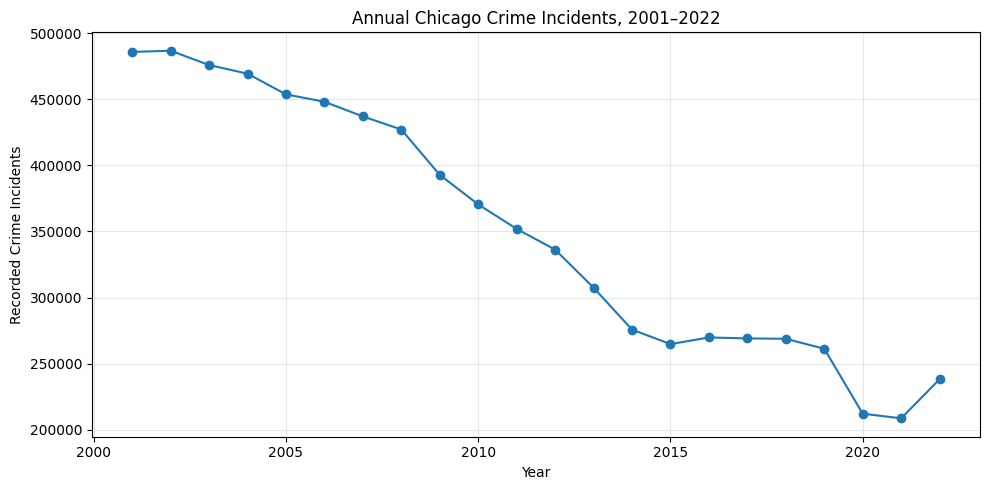

In [91]:
import matplotlib.pyplot as plt

annual_pd = (
    annual_crime
    .filter(
        F.col("Year") <= 2022
    )
    .orderBy("Year")
    .toPandas()
)

plt.figure(figsize=(10, 5))

plt.plot(
    annual_pd["Year"],
    annual_pd["Crime_Count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Recorded Crime Incidents")
plt.title(
    "Annual Chicago Crime Incidents, 2001–2022"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

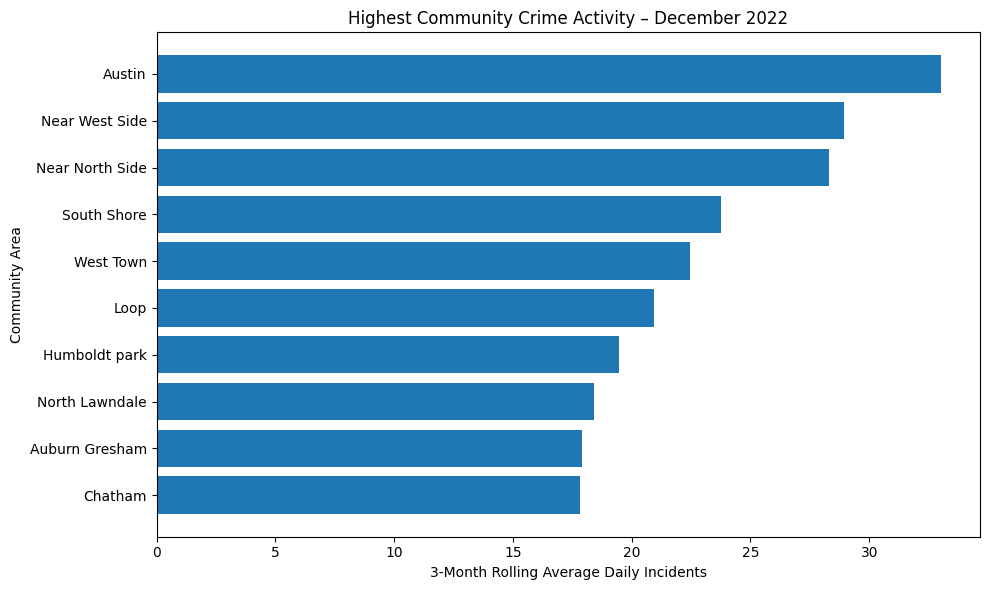

In [92]:
rolling_pd = (
    latest_rolling
    .orderBy(
        F.desc("Rolling_3M_Rate")
    )
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))

plt.barh(
    rolling_pd["Community_Name"][::-1],
    rolling_pd["Rolling_3M_Rate"][::-1]
)

plt.xlabel(
    "3-Month Rolling Average Daily Incidents"
)

plt.ylabel(
    "Community Area"
)

plt.title(
    "Highest Community Crime Activity – December 2022"
)

plt.tight_layout()

plt.show()

In [93]:
weather_chart = spark.sql("""
    SELECT
        CASE
            WHEN w.Precipitation_Event = 1
            THEN 'Precipitation'
            ELSE 'Dry'
        END AS Weather_Group,
        ROUND(
            AVG(d.Daily_Crime_Count),
            2
        ) AS Avg_Daily_Crime
    FROM weather w
    INNER JOIN (
        SELECT
            TO_DATE(Date) AS Crime_Date,
            COUNT(*) AS Daily_Crime_Count
        FROM crime
        WHERE YEAR(Date) BETWEEN 2001 AND 2022
        GROUP BY TO_DATE(Date)
    ) d
        ON w.Weather_Date = d.Crime_Date
    GROUP BY
        CASE
            WHEN w.Precipitation_Event = 1
            THEN 'Precipitation'
            ELSE 'Dry'
        END
""")

weather_chart.show()

+-------------+---------------+
|Weather_Group|Avg_Daily_Crime|
+-------------+---------------+
|Precipitation|         949.32|
|          Dry|         969.42|
+-------------+---------------+



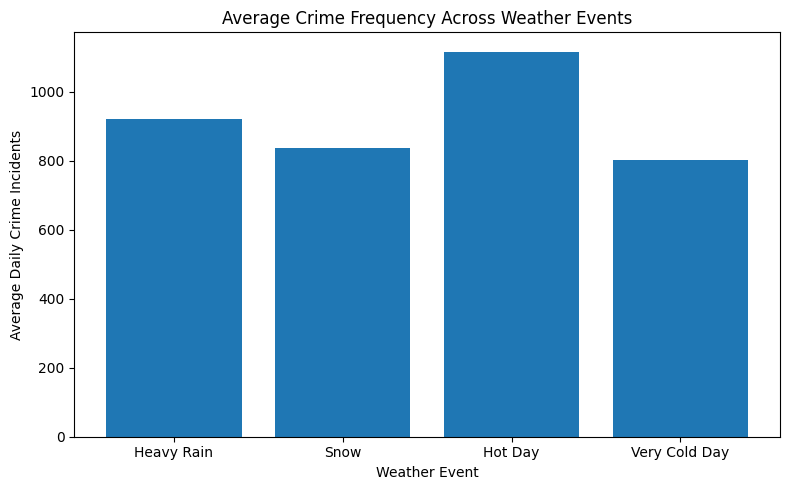

In [95]:
weather_events_report = spark.createDataFrame([
    ("Heavy Rain", 920.65),
    ("Snow", 837.92),
    ("Hot Day", 1116.66),
    ("Very Cold Day", 802.84)
], [
    "Weather_Event",
    "Avg_Daily_Crime"
])

weather_events_pd = weather_events_report.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    weather_events_pd["Weather_Event"],
    weather_events_pd["Avg_Daily_Crime"]
)

plt.ylabel("Average Daily Crime Incidents")
plt.xlabel("Weather Event")

plt.title(
    "Average Crime Frequency Across Weather Events"
)

plt.tight_layout()
plt.show()

## Task 2 Summary

PySpark SQL analysis identified clear temporal and community-level variation in
Chicago crime. Using the complete 2001–2022 period, recorded annual incidents
declined substantially from the early 2000s, while monthly analysis showed the
highest average volumes during July and August. Crime frequency also varied by
time of day, with relatively high shares around midday and during the evening.

A Spark broadcast hash join efficiently attached the 77-row Community Names
lookup to several million crime records. Community-level rolling analysis showed
that Austin had the highest three-month average daily incident rate in December
2022, followed by Near West Side and Near North Side.

For the 2008–2012 period, socio-economic relationships with average daily
incident counts were generally weak. Poverty showed the strongest positive
correlation (r≈0.30), followed by unemployment (r≈0.25), while per-capita income
showed almost no linear relationship. These results are descriptive and are not
interpreted as causal.

Weather analysis covered all 8,035 days from 2001–2022. Maximum and minimum
temperature showed modest positive correlations with daily crime frequency,
while precipitation, snowfall and wind showed weak negative relationships.
Average crime frequency was highest on hot days and lowest on very cold days,
indicating that weather conditions are associated with daily crime variation.

# Task 3 – Unsupervised Spatial-Temporal Clustering

K-Means clustering was applied to latitude, longitude and time-of-day to identify
spatial-temporal crime activity zones. The complete years 2001–2022 were used,
excluding the partial 2023 period.

Because the three clustering variables use different numerical scales,
standardisation was applied before modelling. A reproducible sample was used to
compare candidate values of K using the Silhouette Coefficient, after which the
selected K was fitted to the full spatial dataset.

In [96]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.window import Window

cluster_base = (
    crime
    .filter(
        F.col("Latitude").isNotNull() &
        F.col("Longitude").isNotNull() &
        F.col("Date").isNotNull() &
        F.col("Year").between(2001, 2022)
    )
    .select(
        "ID",
        "District",
        "Latitude",
        "Longitude",
        "Date"
    )
    .withColumn(
        "Hour",
        F.hour("Date").cast("double")
    )
)

print(
    "Records available for clustering:",
    cluster_base.count()
)

Records available for clustering: 7625083


In [97]:
assembler = VectorAssembler(
    inputCols=[
        "Latitude",
        "Longitude",
        "Hour"
    ],
    outputCol="raw_features"
)

cluster_vector = assembler.transform(
    cluster_base
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(
    cluster_vector
)

cluster_ready = (
    scaler_model
    .transform(cluster_vector)
    .select(
        "ID",
        "District",
        "Latitude",
        "Longitude",
        "Hour",
        "features"
    )
    .cache()
)

print(
    "Prepared clustering records:",
    cluster_ready.count()
)

Prepared clustering records: 7625083


In [98]:
k_sample = (
    cluster_ready
    .sample(
        withReplacement=False,
        fraction=0.05,
        seed=42
    )
    .cache()
)

print(
    "K-selection sample:",
    k_sample.count()
)

evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette_results = []

for k in range(2, 7):

    model = KMeans(
        k=k,
        seed=42,
        featuresCol="features",
        predictionCol="prediction",
        maxIter=30
    ).fit(k_sample)

    predictions = model.transform(
        k_sample
    )

    score = evaluator.evaluate(
        predictions
    )

    silhouette_results.append(
        (k, float(score))
    )

    print(
        f"K = {k}, Silhouette = {score:.4f}"
    )

K-selection sample: 381076
K = 2, Silhouette = 0.4848
K = 3, Silhouette = 0.4795
K = 4, Silhouette = 0.4084
K = 5, Silhouette = 0.4141
K = 6, Silhouette = 0.3948


Selected K: 2


,K,Silhouette
0,2,0.484803
1,3,0.479533
2,4,0.408354
3,5,0.414113
4,6,0.394761


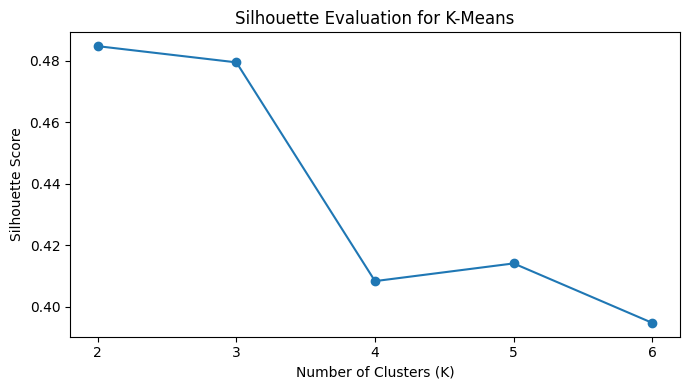

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

silhouette_pd = pd.DataFrame(
    silhouette_results,
    columns=[
        "K",
        "Silhouette"
    ]
)

best_k = int(
    silhouette_pd.loc[
        silhouette_pd["Silhouette"].idxmax(),
        "K"
    ]
)

print("Selected K:", best_k)

display(silhouette_pd)

plt.figure(figsize=(7, 4))

plt.plot(
    silhouette_pd["K"],
    silhouette_pd["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title(
    "Silhouette Evaluation for K-Means"
)

plt.xticks(
    silhouette_pd["K"]
)

plt.tight_layout()
plt.show()

In [100]:
final_kmeans = KMeans(
    k=best_k,
    seed=42,
    featuresCol="features",
    predictionCol="Cluster",
    maxIter=30
)

final_cluster_model = final_kmeans.fit(
    cluster_ready
)

clustered_crime = (
    final_cluster_model
    .transform(cluster_ready)
    .cache()
)

print(
    "Clustered records:",
    clustered_crime.count()
)

Clustered records: 7625083


In [101]:
cluster_summary = (
    clustered_crime
    .groupBy("Cluster")
    .agg(
        F.count("*").alias(
            "Crime_Incidents"
        ),

        F.round(
            F.avg("Latitude"),
            5
        ).alias(
            "Mean_Latitude"
        ),

        F.round(
            F.avg("Longitude"),
            5
        ).alias(
            "Mean_Longitude"
        ),

        F.round(
            F.avg("Hour"),
            2
        ).alias(
            "Mean_Hour"
        )
    )
    .orderBy(
        F.desc("Crime_Incidents")
    )
)

cluster_summary.show(
    truncate=False
)

+-------+---------------+-------------+--------------+---------+
|Cluster|Crime_Incidents|Mean_Latitude|Mean_Longitude|Mean_Hour|
+-------+---------------+-------------+--------------+---------+
|0      |4107025        |41.90729     |-87.70785     |13.07    |
|1      |3518058        |41.76614     |-87.62911     |13.25    |
+-------+---------------+-------------+--------------+---------+



In [102]:
cluster_district_counts = (
    clustered_crime
    .filter(
        F.col("District").isNotNull()
    )
    .groupBy(
        "Cluster",
        "District"
    )
    .count()
)

cluster_totals = (
    clustered_crime
    .filter(
        F.col("District").isNotNull()
    )
    .groupBy("Cluster")
    .count()
    .withColumnRenamed(
        "count",
        "Cluster_Total"
    )
)

district_window = (
    Window
    .partitionBy("Cluster")
    .orderBy(
        F.desc("count")
    )
)

top_district = (
    cluster_district_counts
    .withColumn(
        "Rank",
        F.row_number().over(
            district_window
        )
    )
    .filter(
        F.col("Rank") == 1
    )
    .join(
        cluster_totals,
        on="Cluster"
    )
    .withColumn(
        "Top_District_Share_Pct",
        F.round(
            100 * F.col("count") /
            F.col("Cluster_Total"),
            2
        )
    )
)

district_span = (
    cluster_district_counts
    .groupBy("Cluster")
    .agg(
        F.countDistinct(
            "District"
        ).alias(
            "Districts_Spanned"
        )
    )
)

cluster_alignment = (
    top_district
    .join(
        district_span,
        on="Cluster"
    )
    .select(
        "Cluster",
        F.col("District").alias(
            "Largest_District"
        ),
        "Top_District_Share_Pct",
        "Districts_Spanned"
    )
    .orderBy("Cluster")
)

cluster_alignment.show(
    truncate=False
)

+-------+----------------+----------------------+-----------------+
|Cluster|Largest_District|Top_District_Share_Pct|Districts_Spanned|
+-------+----------------+----------------------+-----------------+
|0      |11              |11.9                  |22               |
|1      |6               |12.7                  |24               |
+-------+----------------+----------------------+-----------------+



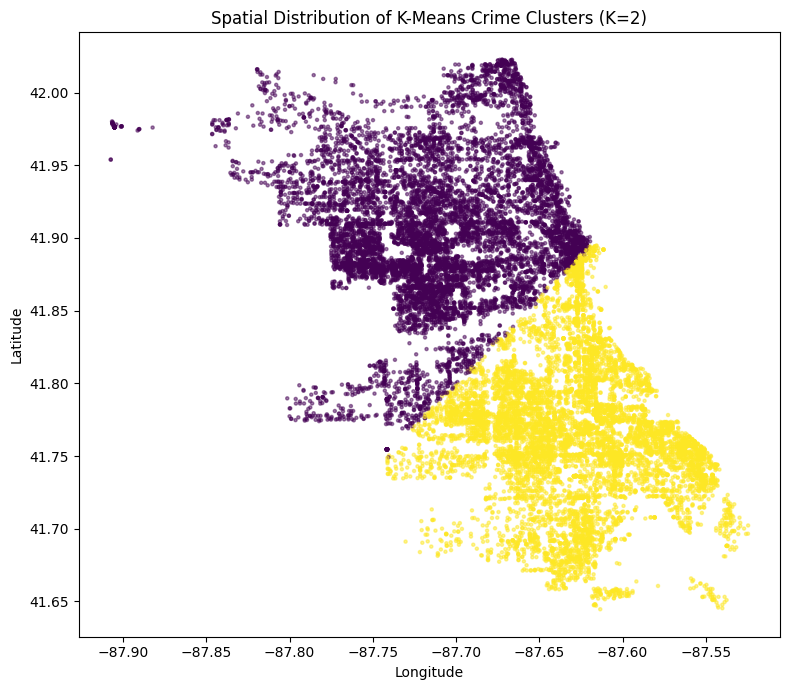

In [103]:
cluster_plot_pd = (
    clustered_crime
    .select(
        "Longitude",
        "Latitude",
        "Cluster"
    )
    .sample(
        False,
        0.003,
        seed=42
    )
    .limit(20000)
    .toPandas()
)

plt.figure(figsize=(8, 7))

plt.scatter(
    cluster_plot_pd["Longitude"],
    cluster_plot_pd["Latitude"],
    c=cluster_plot_pd["Cluster"],
    s=5,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    f"Spatial Distribution of K-Means Crime Clusters (K={best_k})"
)

plt.tight_layout()
plt.show()

## Task 3 Summary

K-Means clustering was applied to standardised latitude, longitude and
time-of-day features for 7,625,083 incidents from the complete 2001–2022
period. A reproducible 5% sample was used to compare candidate values of K
using the Silhouette Coefficient.

K=2 produced the highest Silhouette score (0.4848), narrowly exceeding K=3
(0.4795), while scores declined more substantially for larger values of K.
K=2 was therefore retained as the statistically strongest solution among the
tested candidates.

The two resulting clusters contained approximately 4.11 million and 3.52
million incidents respectively and formed broad northern/north-western and
southern/south-eastern spatial zones. Their similar mean incident hours
(approximately 13:00) indicate that spatial location contributed more strongly
than time-of-day to the final separation.

The clusters did not correspond closely to official police district
boundaries. Cluster 0 spanned 22 police districts and Cluster 1 spanned 24,
while the largest single district accounted for only 11.9% and 12.7% of their
respective incidents. This demonstrates that data-driven activity zones can
cross administrative policing boundaries.

Although K=2 achieved the strongest Silhouette score, it produces relatively
broad operational zones. Increasing K would create more geographically
specific hotspots, but the lower Silhouette scores observed for K=4–6 indicate
weaker statistical separation. The choice of K therefore involves a trade-off
between cluster compactness and operational interpretability.

# Task 4 – Distributed Predictive Modelling

A Spark Random Forest classifier was developed to predict whether a recorded
crime incident resulted in an arrest. Predictors include crime type, police
district, domestic status and temporal characteristics.

The model retains the naturally imbalanced Arrest distribution rather than
artificially balancing the classes. This allows the effect of data skew on
precision and recall to be evaluated directly.

A reproducible 10% sample of the 2001–2022 records is used to keep model
training computationally practical while still providing a large distributed
training dataset.

In [104]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

model_base = (
    crime
    .filter(
        F.col("Arrest").isNotNull() &
        F.col("Primary_Type").isNotNull() &
        F.col("Date").isNotNull() &
        F.col("Year").between(2001, 2022)
    )
    .select(
        "Arrest",
        "Primary_Type",
        "District",
        "Domestic",
        "Date",
        "Year"
    )
    .withColumn(
        "label",
        F.col("Arrest").cast("double")
    )
    .withColumn(
        "District_Str",
        F.coalesce(
            F.col("District").cast("string"),
            F.lit("Unknown")
        )
    )
    .withColumn(
        "Domestic_Num",
        F.when(
            F.col("Domestic") == True,
            1.0
        ).otherwise(0.0)
    )
    .withColumn(
        "Hour",
        F.hour("Date").cast("double")
    )
    .withColumn(
        "Month",
        F.month("Date").cast("double")
    )
    .withColumn(
        "Year_Num",
        F.col("Year").cast("double")
    )
)

model_sample = (
    model_base
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .cache()
)

model_count = model_sample.count()

print(
    "Modelling sample records:",
    model_count
)

Modelling sample records: 771795


In [105]:
arrest_distribution = (
    model_sample
    .groupBy("label")
    .count()
    .withColumn(
        "Percentage",
        F.round(
            100.0 *
            F.col("count") /
            F.lit(model_count),
            2
        )
    )
    .orderBy("label")
)

arrest_distribution.show()

+-----+------+----------+
|label| count|Percentage|
+-----+------+----------+
|  0.0|569536|     73.79|
|  1.0|202259|     26.21|
+-----+------+----------+



In [106]:
train_data, test_data = (
    model_sample
    .randomSplit(
        [0.80, 0.20],
        seed=42
    )
)

train_data = train_data.cache()
test_data = test_data.cache()

print(
    "Training records:",
    train_data.count()
)

print(
    "Testing records:",
    test_data.count()
)

Training records: 617223
Testing records: 154572


In [107]:
primary_indexer = StringIndexer(
    inputCol="Primary_Type",
    outputCol="Primary_Type_Index",
    handleInvalid="keep"
)

district_indexer = StringIndexer(
    inputCol="District_Str",
    outputCol="District_Index",
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=[
        "Primary_Type_Index",
        "District_Index",
        "Domestic_Num",
        "Hour",
        "Month",
        "Year_Num"
    ],
    outputCol="features"
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=50,
    maxDepth=8,
    maxBins=64,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        primary_indexer,
        district_indexer,
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(
    train_data
)

predictions = rf_model.transform(
    test_data
).cache()

print(
    "Test predictions:",
    predictions.count()
)

Test predictions: 154572


In [108]:
confusion_matrix = (
    predictions
    .groupBy(
        "label",
        "prediction"
    )
    .count()
    .orderBy(
        "label",
        "prediction"
    )
)

confusion_matrix.show()

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|113286|
|  0.0|       1.0|   736|
|  1.0|       0.0| 21273|
|  1.0|       1.0| 19277|
+-----+----------+------+



In [109]:
cm_rows = {
    (
        int(row["label"]),
        int(row["prediction"])
    ): row["count"]
    for row in confusion_matrix.collect()
}

TN = cm_rows.get((0, 0), 0)
FP = cm_rows.get((0, 1), 0)
FN = cm_rows.get((1, 0), 0)
TP = cm_rows.get((1, 1), 0)

precision = (
    TP / (TP + FP)
    if (TP + FP) > 0
    else 0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) > 0
    else 0
)

f1 = (
    2 * precision * recall /
    (precision + recall)
    if (precision + recall) > 0
    else 0
)

accuracy = (
    (TP + TN) /
    (TP + TN + FP + FN)
)

print("True Negatives :", TN)
print("False Positives :", FP)
print("False Negatives :", FN)
print("True Positives :", TP)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1-Score  : {f1:.4f}"
)

True Negatives : 113286
False Positives : 736
False Negatives : 21273
True Positives : 19277
Accuracy  : 0.8576
Precision : 0.9632
Recall    : 0.4754
F1-Score  : 0.6366


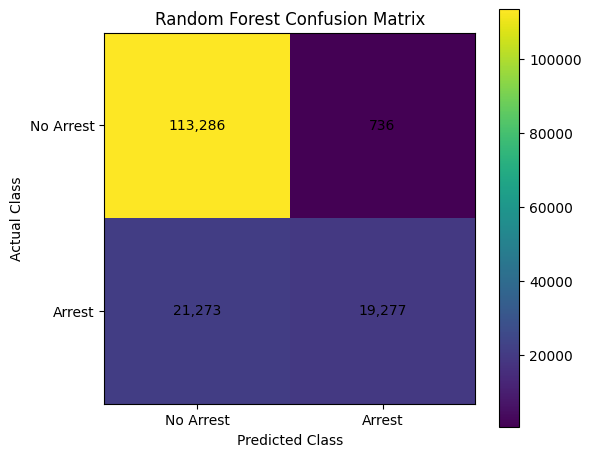

In [112]:
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Arrest", "Arrest"]
)

plt.yticks(
    [0, 1],
    ["No Arrest", "Arrest"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Random Forest Confusion Matrix"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [110]:
roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

roc_auc = roc_evaluator.evaluate(
    predictions
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

ROC-AUC: 0.8404


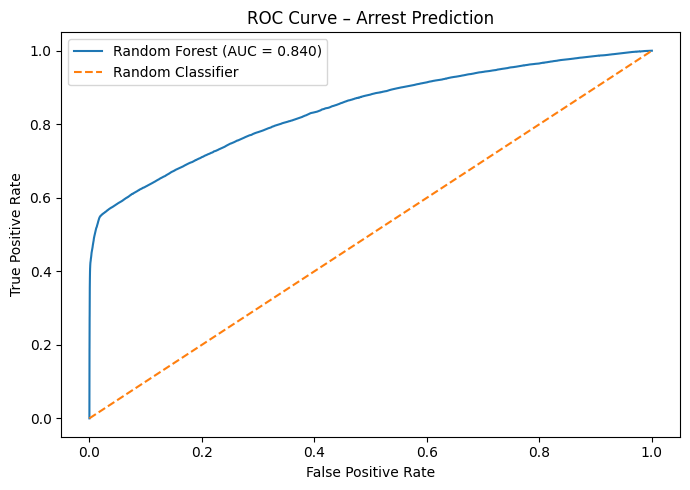

In [113]:
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc

roc_pd = (
    predictions
    .select(
        "label",
        vector_to_array(
            "probability"
        )[1].alias(
            "Arrest_Probability"
        )
    )
    .toPandas()
)

fpr, tpr, thresholds = roc_curve(
    roc_pd["label"],
    roc_pd["Arrest_Probability"]
)

roc_auc_plot = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_plot:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve – Arrest Prediction"
)

plt.legend()

plt.tight_layout()
plt.show()

In [111]:
rf_stage = rf_model.stages[-1]

feature_names = [
    "Primary Type",
    "District",
    "Domestic",
    "Hour",
    "Month",
    "Year"
]

feature_importance = [
    (
        feature_names[i],
        float(value)
    )
    for i, value in enumerate(
        rf_stage.featureImportances
    )
]

feature_importance_df = spark.createDataFrame(
    feature_importance,
    [
        "Feature",
        "Importance"
    ]
)

feature_importance_df.orderBy(
    F.desc("Importance")
).show(
    truncate=False
)

+------------+---------------------+
|Feature     |Importance           |
+------------+---------------------+
|Primary Type|0.9375921208786169   |
|District    |0.024160891548727963 |
|Year        |0.0178459327578517   |
|Domestic    |0.010099775071137471 |
|Hour        |0.010033026353343947 |
|Month       |2.6825339032207987E-4|
+------------+---------------------+



## Task 4 Summary

A distributed Random Forest classifier was developed in PySpark to predict the
likelihood of arrest using crime type, police district, domestic status and
temporal attributes. A reproducible 10% sample provided 771,795 observations,
with 73.79% representing no-arrest cases and 26.21% representing arrest cases.

On the held-out test set, the model achieved 85.76% accuracy and an ROC-AUC of
0.8404, indicating useful overall discriminatory ability. Precision for the
arrest class was high at 96.32%, while recall was substantially lower at
47.54%, producing an F1-score of 63.66%.

The confusion matrix showed only 736 false-positive arrest predictions but
21,273 false negatives. This demonstrates the effect of class imbalance: the
classifier strongly favoured the majority no-arrest class and was conservative
when predicting arrests. Consequently, accuracy alone would overstate model
performance, making precision, recall, F1-score and ROC-AUC more informative
evaluation measures.

Feature importance was dominated by Primary Type, which accounted for
approximately 93.8% of the model's impurity-based importance. District, year,
domestic status and hour contributed comparatively smaller amounts. These
importance values describe predictive contribution within the Random Forest
and should not be interpreted as causal effects.

Overall, the model provides useful predictive discrimination but its limited
recall means that a substantial proportion of actual arrest cases remain
undetected. Future modelling could explore class weighting, threshold tuning
or alternative classifiers to improve minority-class recall.